In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

Libraries loaded ✓


In [9]:
df = pd.read_csv('../data/raw/tracks.csv')
df_clean = df[df['tempo'] > 0].copy()

group_colors = {'A_focus': '#2196F3', 'B_context': '#4CAF50'}
group_labels = {'A_focus': 'A — Focus', 'B_context': 'B — Context'}

pop_A = df_clean[df_clean['group'] == 'A_focus']['popularity'].values
pop_B = df_clean[df_clean['group'] == 'B_context']['popularity'].values

print(f'A_focus: n={len(pop_A)}, mean={pop_A.mean():.2f}')
print(f'B_context: n={len(pop_B)}, mean={pop_B.mean():.2f}')

A_focus: n=947, mean=28.47
B_context: n=1069, mean=31.89


## Bayesian A/B Test

**Approach:** Beta-Binomial conjugate model with uniform prior Beta(1,1).

**Binary outcome:** did a track reach mainstream popularity (popularity ≥ 50)?
- 1 = mainstream popular
- 0 = not mainstream popular

**Why ≥ 50?** This threshold represents tracks that are genuinely popular,
not just above average. It matches the binary outcome used in the frequentist
chi-squared test in Notebook 2, enabling direct comparison between both approaches.

**Prior:** Beta(1,1) — uniform, no prior assumption about which group is better.
**Posterior:** Beta(1 + successes, 1 + failures) — updated with observed data.

In [10]:
THRESHOLD = 50

success_A = (pop_A >= THRESHOLD).sum()
success_B = (pop_B >= THRESHOLD).sum()
n_A, n_B = len(pop_A), len(pop_B)

print(f'Tracks with popularity >= {THRESHOLD}:')
print(f'  A_focus:   {success_A}/{n_A} ({success_A/n_A*100:.1f}%)')
print(f'  B_context: {success_B}/{n_B} ({success_B/n_B*100:.1f}%)')

# Posterior: Beta(1 + successes, 1 + failures)
alpha_A = 1 + success_A
beta_A  = 1 + (n_A - success_A)
alpha_B = 1 + success_B
beta_B  = 1 + (n_B - success_B)

print(f'\nPosterior A: Beta({alpha_A}, {beta_A})')
print(f'Posterior B: Beta({alpha_B}, {beta_B})')

Tracks with popularity >= 50:
  A_focus:   139/947 (14.7%)
  B_context: 217/1069 (20.3%)

Posterior A: Beta(140, 809)
Posterior B: Beta(218, 853)


In [11]:
np.random.seed(42)
N_SAMPLES = 20000

samples_A = np.random.beta(alpha_A, beta_A, N_SAMPLES)
samples_B = np.random.beta(alpha_B, beta_B, N_SAMPLES)

prob_B_gt_A = (samples_B > samples_A).mean()
print(f'P(Context > Focus): {prob_B_gt_A:.4f}')
print(f'P(Focus > Context): {1 - prob_B_gt_A:.4f}')

lift = (samples_B - samples_A) / samples_A * 100
print(f'\nMedian lift (Context over Focus): {np.median(lift):.1f}%')
print(f'95% Credible Interval: [{np.percentile(lift, 2.5):.1f}%, {np.percentile(lift, 97.5):.1f}%]')

P(Context > Focus): 0.9998
P(Focus > Context): 0.0002

Median lift (Context over Focus): 38.1%
95% Credible Interval: [14.3%, 68.4%]


## Bayesian Results

| Metric | Value |
|--------|-------|
| P(Context > Focus) | 0.9998 |
| P(Focus > Context) | 0.0002 |
| Median lift | 38.1% |
| 95% Credible Interval | [14.3%, 68.4%] |

**Interpretation:**
- There is 99.98% probability that Context tracks have higher mainstream popularity than Focus tracks
- Context tracks have ~38% more tracks above the popularity ≥ 50 threshold
- The credible interval is wide [14%, 68%] — the effect is real but uncertain in magnitude
- Consistent with the frequentist chi-squared result (p=0.0012)

**Both approaches agree:** Context music scores higher on Spotify's popularity metric.
However, popularity is a proxy — it reflects how many people choose to listen,
not whether they stayed focused or engaged longer.
And critically, this difference is not driven by BPM —
Focus and Context tracks have nearly identical tempo distributions.

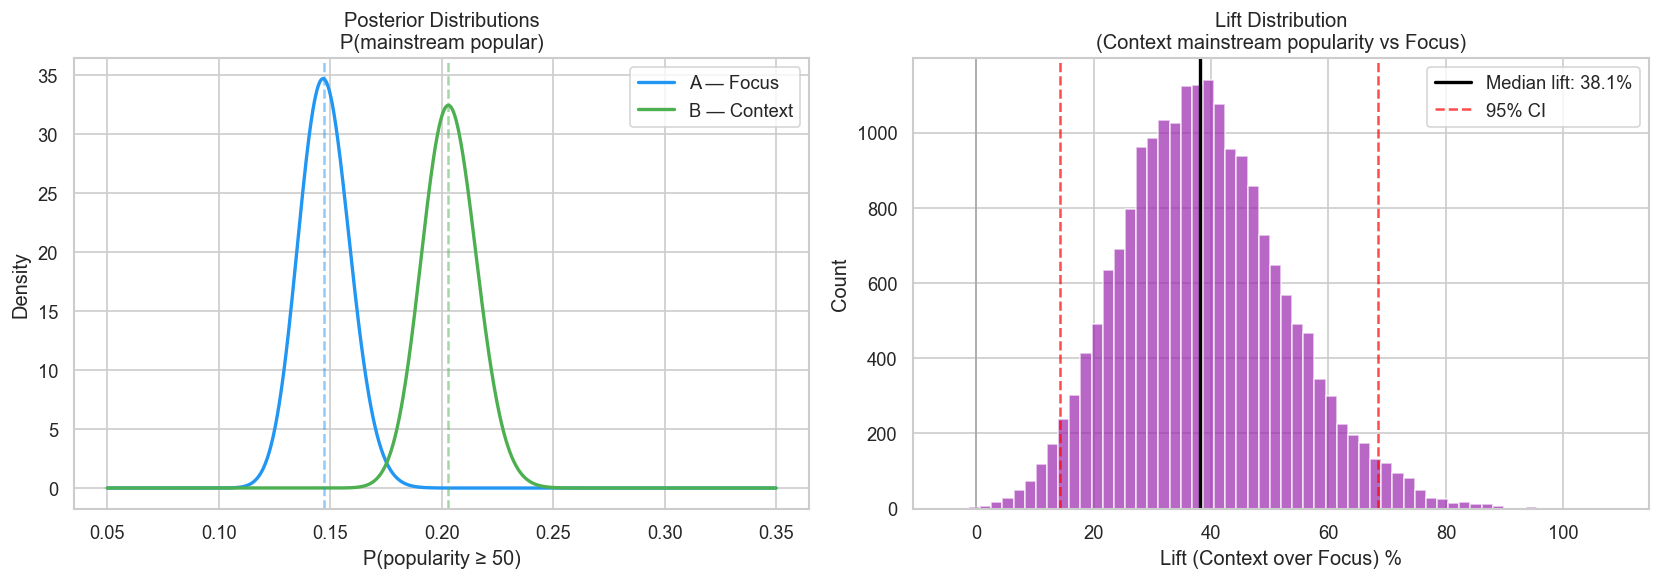

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior distributions
x = np.linspace(0.05, 0.35, 1000)
axes[0].plot(x, stats.beta.pdf(x, alpha_A, beta_A), color='#2196F3', linewidth=2, label='A — Focus')
axes[0].plot(x, stats.beta.pdf(x, alpha_B, beta_B), color='#4CAF50', linewidth=2, label='B — Context')
axes[0].axvline(0.147, color='#2196F3', linestyle='--', alpha=0.5)
axes[0].axvline(0.203, color='#4CAF50', linestyle='--', alpha=0.5)
axes[0].set_xlabel('P(popularity ≥ 50)')
axes[0].set_ylabel('Density')
axes[0].set_title('Posterior Distributions\nP(mainstream popular)')
axes[0].legend()

# Lift distribution
axes[1].hist(lift, bins=60, color='#9C27B0', alpha=0.7, edgecolor='white')
axes[1].axvline(np.median(lift), color='black', linewidth=2, label=f'Median lift: {np.median(lift):.1f}%')
axes[1].axvline(np.percentile(lift, 2.5), color='red', linestyle='--', alpha=0.7, label='95% CI')
axes[1].axvline(np.percentile(lift, 97.5), color='red', linestyle='--', alpha=0.7)
axes[1].axvline(0, color='gray', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Lift (Context over Focus) %')
axes[1].set_ylabel('Count')
axes[1].set_title('Lift Distribution\n(Context mainstream popularity vs Focus)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/full_06_bayesian_posteriors.png', dpi=120, bbox_inches='tight')
plt.show()

## Bayesian Posteriors — Visualization

**Left — Posterior distributions:**
- Focus (blue) centered at ~14.7% — about 1 in 7 focus tracks reaches mainstream popularity
- Context (green) centered at ~20.3% — about 1 in 5 context tracks reaches mainstream popularity
- Distributions are clearly separated with minimal overlap — consistent with P(Context > Focus) = 0.9998

**Right — Lift distribution:**
- Entire distribution is above 0 — Context always wins in the simulation
- Median lift of 38.1% with 95% CI [14.3%, 68.4%]
- Wide CI reflects genuine uncertainty about the magnitude, not the direction

**Comparison with Notebook 2 (frequentist):**
- Chi-squared: p=0.0012 ✓ significant
- Bayesian: P(Context > Focus) = 0.9998 ✓ consistent
- Both approaches agree — the difference is real and in the same direction